# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: XX     | 9 |
| :-------------|:-------------|
| Jens Groen | 635991 |
| Tobias van Bavel | 6436404 |

In [90]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
from scipy.optimize import curve_fit
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m) gff

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

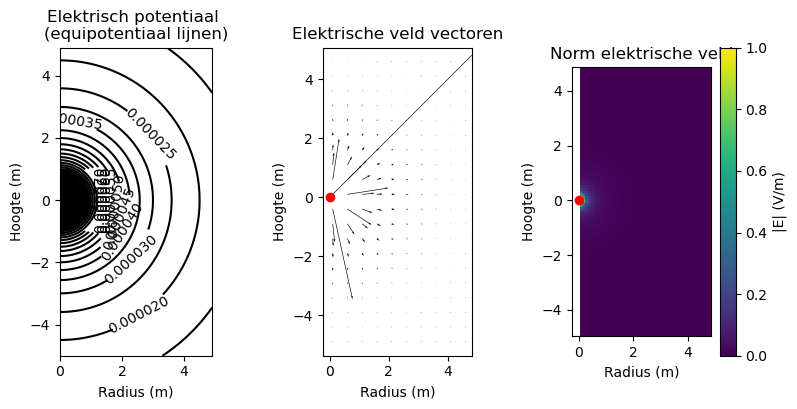

In [91]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

50
-1.0
het exponent is: -1.0


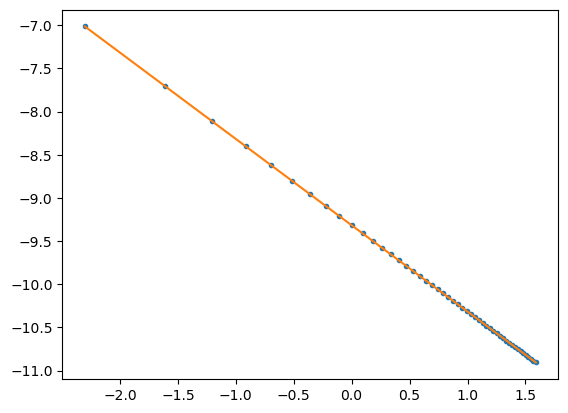

In [92]:

###
# zoek naar de index die correspondeert met z = 0
indexz0 = None
for i in range (len(z)):
    if abs(z[i]) < 1e-10:
        indexz0 = i
        break
print(indexz0)
V_z0 = V[indexz0, :]

#mask maken voor
mask = r != 0

#log nemen van radius
#log nemen van potentiaal
rlog = np.log(r[mask])
Vlog = np.log(V_z0[mask])
plt.plot(rlog, Vlog, ".")

#fitfunctie
def functie(x,a,b):
    y = a*x+b
    return y

#curvefit, lineaire fit
popt, pcov = curve_fit(functie,rlog,Vlog)


fitx = np.linspace(np.min(rlog),np.max(rlog),1001)
fity = functie(fitx,popt[0],popt[1])
plt.plot(fitx,fity)

#exponent
print(popt[0])
print("het exponent is:", popt[0])
###

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

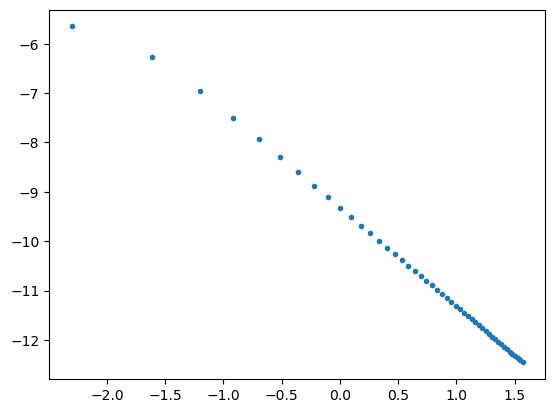

In [93]:
###
#normE is grootte van electrisch veld op een punt
Eplot = normE[50, :]

plt.figure()
plt.plot(np.log(r_for_E), np.log(Eplot), '.')
###

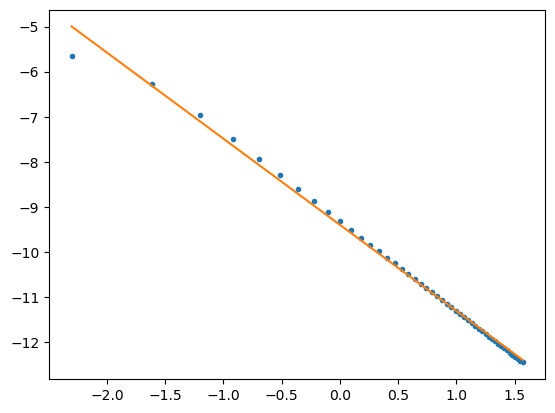

In [94]:
#E fitten
val, cov = curve_fit(functie, np.log(r_for_E), np.log(Eplot))
xtest = np.linspace(np.min(np.log(r_for_E)), np.max(np.log(r_for_E)), 500)
ytest = functie(xtest,*val)


plt.figure()
plt.plot(np.log(r_for_E), np.log(Eplot), '.')
plt.plot(xtest, ytest)

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [121]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius =  1  # (m)
grid_step = 0.05  # (m)
z_coord_DISK = 0  # (m) positie van de schijf opa de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

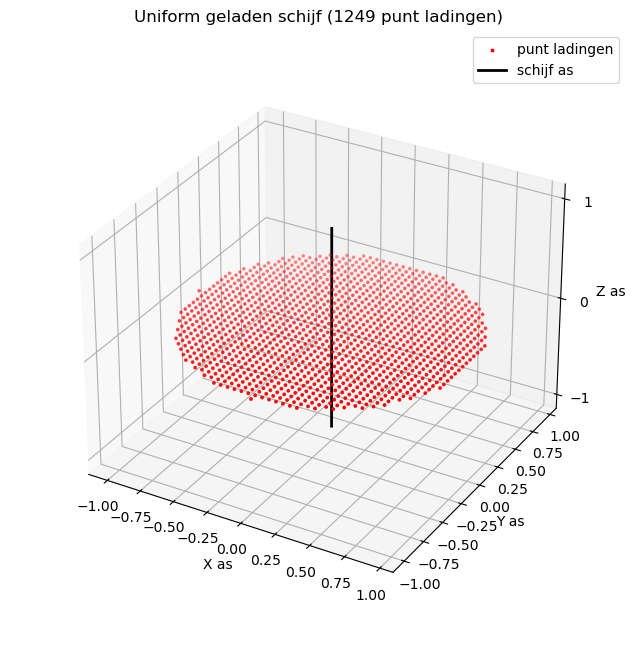

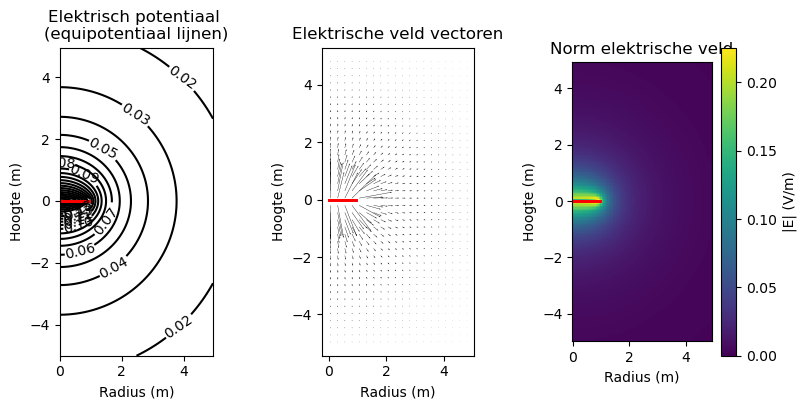

In [122]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. de radius van de cirkel die opgevult wordt door de puntladingen wordt kleiner

2. De puntladingen komen dichter bij elkaar te staan, waardoor er meer passen in de cirkel

3. z-coord is de hoogte van de disk

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [123]:
###
#oppervlakte
A = np.pi * disk_radius**2
# Totale Lading
Q = number_point_charges_on_disk * charge_one_point

#ladingsdichtheid
sigma = Q/A
print("De ladingsdichtheid sigma =" , sigma , "C/m^2")
###

De ladingsdichtheid sigma = 3.975690478435546e-12 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

indexz0 = 100 z = -1.7763568394002505e-14
indexr0 = 0 r = 0.0
V_0 = 0.21818491878144494


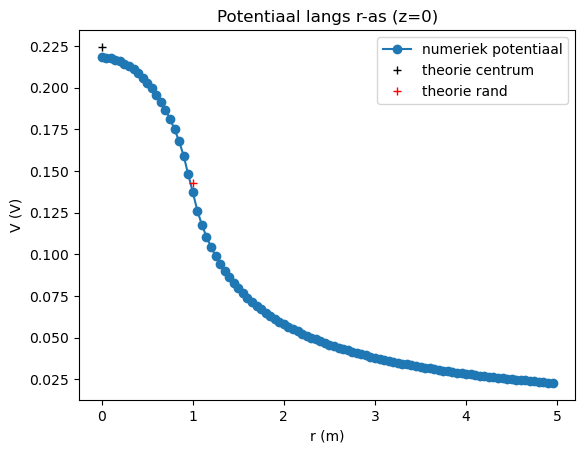

In [124]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.

e0 = 8.85418782*10**-12

def rand(sigma, R, e0):
    #electriscch potentiaal formule van een ronde schijf aan de rand
    Vrand = sigma * R/(np.pi * e0)
    return Vrand

def center(sigma, R, e0):
        #electriscch potentiaal formule van een ronde schijf in het centrum
    Vcenter = sigma * R/(2 * e0)
    return Vcenter

Vrand = rand(sigma, disk_radius, e0)
Vcenter = center(sigma, disk_radius, e0)

# index voor z = 0
indexz0 = None
for i in range(len(z)):
    if abs(z[i]) < 1e-10:
        indexz0 = i
        break

# index voor r = 0
indexr0 = None
for j in range(len(r)):
    if abs(r[j]) < 1e-10:
        indexr0 = j
        break

print("indexz0 =", indexz0, "z =", z[indexz0])
print("indexr0 =", indexr0, "r =", r[indexr0])

# numeriek potentiaal op (z=0, r=0)
V_0 = V[indexz0, indexr0]
print("V_0 =", V_0)

# numeriek potentiaal langs de r-as bij z = 0
V_R = V[indexz0, :]
r_R = r

plt.title("Potentiaal langs r-as (z=0)")
plt.plot(r_R, V_R, "o-", label="numeriek potentiaal")

# theorie
plt.plot(0, Vcenter, "k+", label="theorie centrum")
plt.plot(disk_radius, Vrand, "r+", label="theorie rand")

#numeriek centrum

plt.legend()
plt.xlabel("r (m)")
plt.ylabel("V (V)")
plt.show()

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


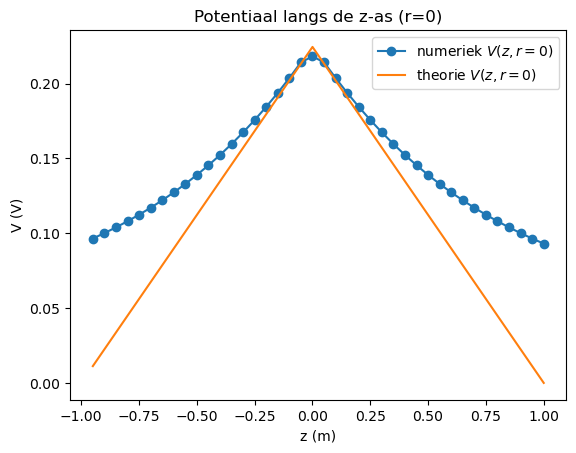

In [125]:
###
def V_theorie(sigma,e0,R,z):
    V = sigma/(2*e0) * (R - np.abs(z))
    return V

V_num_z = V[:, indexr0]

# R>>z
mask = np.abs(z) <= disk_radius

###
plt.figure()
plt.plot(z[mask], V_num_z[mask], "o-", label="numeriek $V(z, r=0)$")
plt.plot(z[mask], V_theorie(sigma, e0, disk_radius, z[mask]), "-", label="theorie $V(z, r=0)$")
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.title("Potentiaal langs de z-as (r=0)")
plt.legend()
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

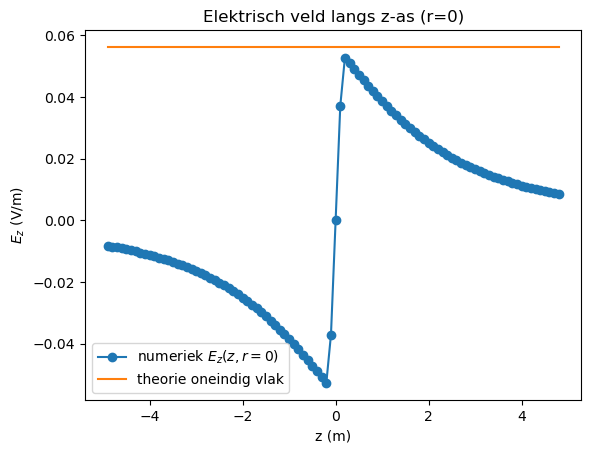

In [100]:
# index van r = 0 zoeken in r_for_E (niet in r!)
indexr0_E = None
for i in range(len(r_for_E)):
    if abs(r_for_E[i]) < 1e-10:
        indexr0_E = i
        break

# numeriek Ez op de z-as (r = 0)
E_num_z = Ez[:, 0, indexr0_E]

# theoretisch veld van oneindig vlak
E0 = sigma / (2 * e0)
#npsign maakt alles -1, 0 of 1 van, dus -5 wordt -1 en 5 wordt 1
E_theorie =  np.abs(E0 * np.sign(z_for_E))

# plot
plt.figure()
plt.plot(z_for_E, E_num_z, "o-", label="numeriek $E_z(z,r=0)$")
plt.plot(z_for_E, E_theorie, "-", label="theorie oneindig vlak")

plt.xlabel("z (m)")
plt.ylabel("$E_z$ (V/m)")
plt.title("Elektrisch veld langs z-as (r=0)")
plt.legend()

plt.savefig("vraag_2e.png", dpi=300)
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?

2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.


##### Antwoorden 2f

1. Dichtbij de z = 0
2. In de plot wijkt het numerieke veld af van de theorie van een oneindige plaat doordat de schijf eindig is. Dicht bij het centrum en voor kleine |z| komt het veld overeen met dat van een oneindige plaat, maar voor grotere afstanden neemt het veld af omdat de schijf zich dan gedraagt als een puntlading. Daarnaast is de sprong bij z = 0 niet perfect scherp door de eindige roosterstap en de numerieke benadering.

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

radius = 1 m
grid_step = 0.05 m


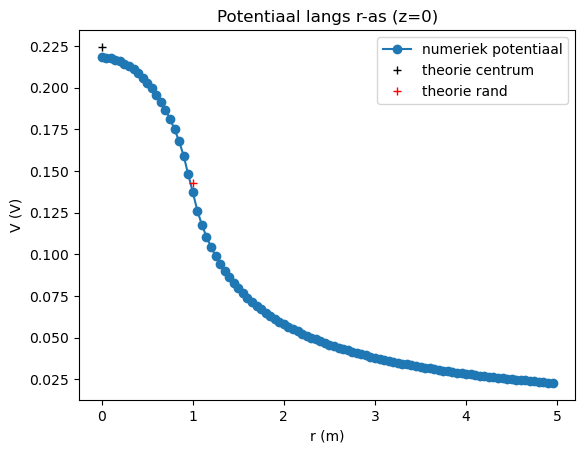

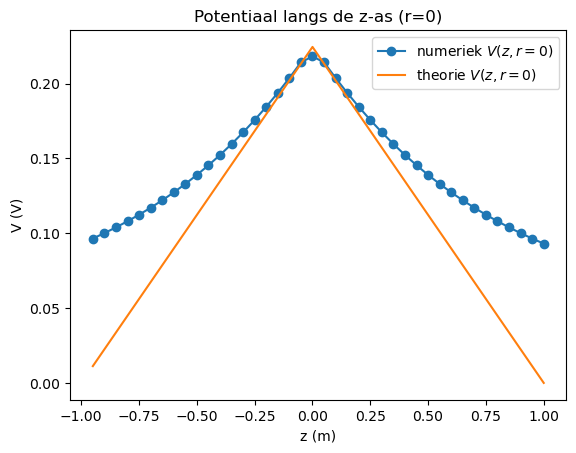

FileNotFoundError: No such file or directory: 'figures/functies.png'

FileNotFoundError: No such file or directory: 'figures/functies.png'

<IPython.core.display.Image object>

In [126]:
###
print("radius = 1 m")
print("grid_step = 0.05 m")
###
display(Image("figures/1.png"))
display(Image("figures/2.png"))
display(Image("figures/functies.png"))

##### Antwoorden 2g

1. De potentiaal langs de r-as curve is stijler


#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

Voor een oneindige plaat geldt:

E₀ = σ / (2ε₀)

We zoeken de hoogte z waarvoor het veld van de schijf gelijk is aan 10% van dit veld:

E(z) = 0.1 E₀

Invullen in de formule voor het veld van de schijf:

E₀ (1 − z / √(R² + z²)) = 0.1 E₀

Delen door E₀ geeft:

1 − z / √(R² + z²) = 0.1

Dus:

z / √(R² + z²) = 0.9

Kwadrateren:

z² / (R² + z²) = 0.81

z² = 0.81 (R² + z²)

z² = 0.81R² + 0.81z²

0.19z² = 0.81R²

z² = (0.81 / 0.19) R²

z ≈ 2.06 R

Dus het veld is 10% van dat van een oneindige plaat op een hoogte van ongeveer z ~ 2.06R boven de schijf.


### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

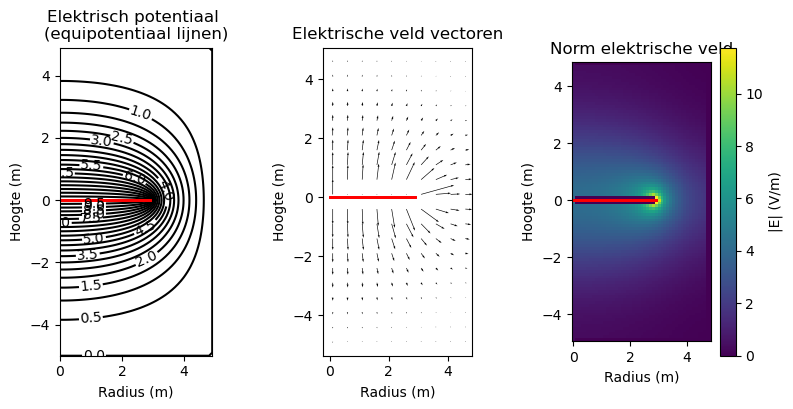

In [102]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

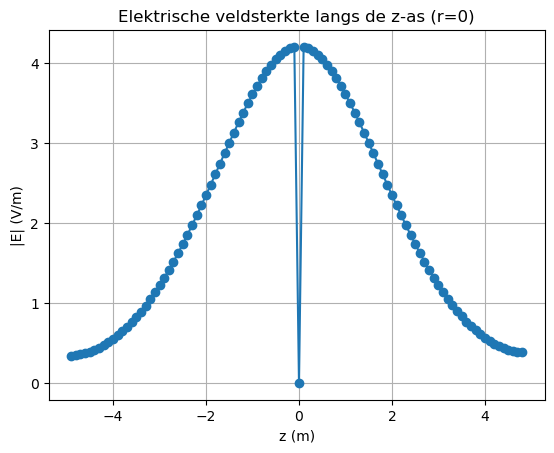

E dichtbij center (net boven de schijf) = [0.3838989]
bij z = 4.799999999999965 m en r = 0


In [103]:
# 1) Plot |E| op de z-as (r = 0)

# index van r = 0 zoeken in r_for_E
indexr0_E = None
for i in range(len(r_for_E)):
    if abs(r_for_E[i]) < 1e-10:
        indexr0_E = i
        break

# E-norm op de z-as
E_axis = normE[:, 0, indexr0_E]

# z = 0 punt verwijderen uit plot
z_plot = []
E_plot = []

#zoeken welke index z = 0 in z for E
for k in range(len(z_for_E)):
    if abs(z_for_E[k]) >= 0:   # z ≠ 0
        z_plot.append(z_for_E[k])
        E_plot.append(E_axis[k])

plt.figure()
plt.plot(z_plot, E_plot, "o-")
plt.xlabel("z (m)")
plt.ylabel("|E| (V/m)")
plt.title("Elektrische veldsterkte langs de z-as (r=0)")
plt.grid(True)
plt.show()


# 2) Print |E| net boven het midden (z > 0, r = 0)

#zoeken welke index net boven 0 is
indexz_plus = None
for j in range(len(z_for_E)):
    if z_for_E[j] > 0:
        indexz_plus = j

#E near center is index van z for E
E_near_center = E_axis[indexz_plus]

print("E dichtbij center (net boven de schijf) =", E_near_center)
print("bij z =", z_for_E[indexz_plus], "m en r = 0")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

*Geef in deze markdown cel je antwoord op 3b.1.*

In [104]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.

# index r=0 in r_for_E
indexr0_E = None
for i in range(len(r_for_E)):
    if abs(r_for_E[i]) < 1e-10:
        indexr0_E = i

# index van eerste z-punt BOVEN 0 (z > 0) in z_for_E
indexz_plus = None
for j in range(len(z_for_E)):
    if z_for_E[j] > 0:
        indexz_plus = j

# neem Ez net boven de schijf, op de as (r=0)
Ez_plus = Ez[indexz_plus, 0, indexr0_E]   # Ez is 3D: (Nz, 1, Nr)

# σ ≈ ε0 * Ez
sigma_center = e0 * Ez_plus

print("Benadering oppervlaktelading in het midden (r=0):")
print("index z net boven de schijf =", indexz_plus)
print("Ez net boven de schijf (V/m) =", Ez_plus)
print("sigma(0) ≈ ε0 * Ez (C/m^2) =", sigma_center)

Benadering oppervlaktelading in het midden (r=0):
index z net boven de schijf = 97
Ez net boven de schijf (V/m) = [0.3838989]
sigma(0) ≈ ε0 * Ez (C/m^2) = [3.39911299e-12]


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


[9.61076555e-11]
sigma_center (geleidende schijf) = [3.39911299e-12]
sigma_uniform (zelfde Q)         = [3.39911299e-12]
ratio = [1.]


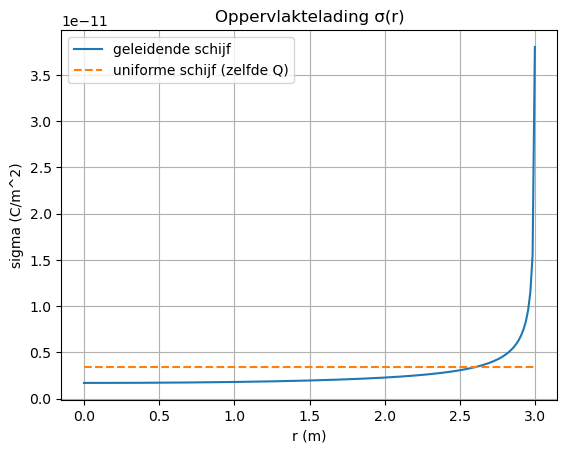

In [105]:
### 1
#formule oppervlaktelading
def oppervlaktelading(R,sigma):
    Q = np.pi*R**2*sigma
    return Q

Q = oppervlaktelading(disk_radius,sigma_center)

print(Q)

### 2
R = disk_radius

#sigma voor een uniforme schijf:  lading verdelen over opp
sigma_uniform = Q / (np.pi * R**2)

print("sigma_center (geleidende schijf) =", sigma_center)
print("sigma_uniform (zelfde Q)         =", sigma_uniform)
print("ratio =", sigma_center / sigma_uniform)

### 3

# r-waarden van 0 tot net onder R (anders krijg je divide bij 0)
r_plot = np.linspace(0, R*0.999, 200)

# sigma(r) voor geleidende schijf
sigma_cond = Q / (2 * np.pi * R * np.sqrt(R**2 - r_plot**2))

# Uniforme schijf (zelfde Q)
#npones maakt een array met de lengte van r_plot en dus wordt het een array met alleen maar sigma_uniform
sigma_uniform_plot = sigma_uniform * np.ones_like(r_plot)

plt.figure()
plt.plot(r_plot, sigma_cond, label="geleidende schijf")
plt.plot(r_plot, sigma_uniform_plot, "--", label="uniforme schijf (zelfde Q)")

plt.xlabel("r (m)")
plt.ylabel("sigma (C/m^2)")
plt.title("Oppervlaktelading σ(r)")
plt.legend()
plt.grid(True)
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [106]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.

#zoek naar de grootste waarde
E_max = np.max(normE)


iz_max = None
ir_max = None

#zoek het punt waar E_max is
for iz in range(len(z_for_E)):
    for ir in range(len(r_for_E)):
        if normE[iz, ir] == E_max:
            iz_max = iz
            ir_max = ir
            break

print("Maximum |E| =", E_max, "V/m")
print("Locatie van maximum:")
print("z =", z_for_E[iz_max], "m")
print("r =", r_for_E[ir_max], "m")


# E_near_center = E_axis[indexz_plus]
E_center = E_near_center[0]  

verschil = E_max - E_center
factor = E_max / E_center

print("------------------------------------------------")
print("Vergelijking met het veld in het midden (r=0, net boven z=0):")
print("E_center =", E_center, "V/m")
print("Verschil =", verschil, "V/m")

Maximum |E| = 11.752993215742134 V/m
Locatie van maximum:
z = 0.09999999999998188 m
r = 3.0 m
------------------------------------------------
Vergelijking met het veld in het midden (r=0, net boven z=0):
E_center = 0.38389890241733765 V/m
Verschil = 11.369094313324796 V/m


##### Antwoord 3d.5

Het hoge veld ontstaat doordat lading zich ophoopt aan de rand van de geleider om het potentiaal constant te houden.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

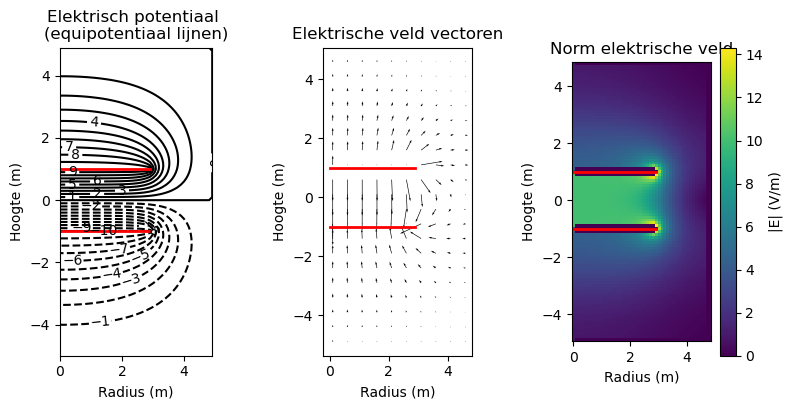

In [107]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


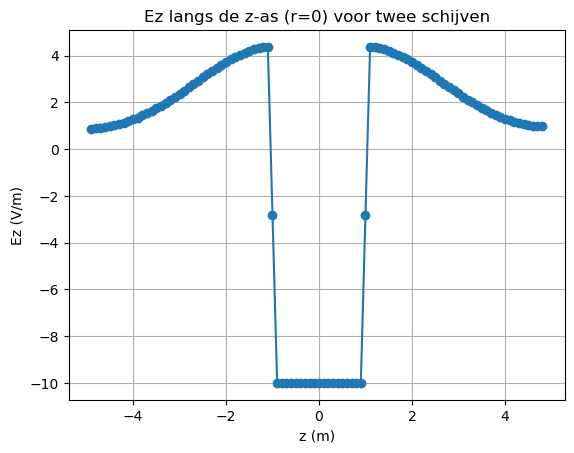

In [108]:
###
# 4a.1 Plot Ez op de z-as (r = 0)

# index van r = 0 zoeken in r_for_E
indexr0_E = None
for i in range(len(r_for_E)):
    if abs(r_for_E[i]) < 1e-10:
        indexr0_E = i
        break

# Ez langs de z-as (r=0)
Ez_axis = Ez[:, 0, indexr0_E] 

plt.figure()
plt.plot(z_for_E, Ez_axis, "o-")
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.title("Ez langs de z-as (r=0) voor twee schijven")
plt.grid(True)
plt.show()
###

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b
1. 

E= 0

|

|

E = 4.201845192612321 V/m

----------------------------- | + | <-plaat 1  E = 0

E ~ - (v1 - v2)/d = -10

----------------------------- | - | <-plaat 2 E = 0

E = 4.201845192612321 V/m
 
|

|

E = 0


2. E = - (v1 - v2)/d = -10 - Ja komt overeen


3. twee schijven geven een veel beter gecontroleerd, bijna homogeen veld  dan één schijf.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [109]:
###
import numpy as np

e0 = 8.85418782e-12

R = disk_radius
d = spacing_between_disks
deltaV = V1 - V2

A = np.pi * R**2 #opp schijf

#ideale condensator geldt:
E_ideal = deltaV / d

#ladingsdichtheid formule vlakke plaat
sigma_in = e0 * E_ideal

#totale lading op één plaat, lading = ladingsdichtheid * oppervlakte
Q_one = sigma_in * A         
Q_top = +Q_one
Q_bottom = -Q_one
Q_total = abs(Q_top) + abs(Q_bottom)

C = Q_one / deltaV            # = e0*A/d

print("E ≈ ΔV/d =", E_ideal, "V/m")
print("σ_in ≈ ε0*E =", sigma_in, "C/m^2")
print("Q (per schijf, binnenzijde) ≈ σ_in*A =", Q_one, "C")
print("Q_boven ≈", Q_top, "C")
print("Q_onder ≈", Q_bottom, "C")
print("|Q_boven| + |Q_onder| ≈", Q_total, "C")
print("C = Q/ΔV ≈ ε0*A/d =", C, "F")
###

E ≈ ΔV/d = 10.0 V/m
σ_in ≈ ε0*E = 8.85418782e-11 C/m^2
Q (per schijf, binnenzijde) ≈ σ_in*A = 2.5034626267934603e-09 C
Q_boven ≈ 2.5034626267934603e-09 C
Q_onder ≈ -2.5034626267934603e-09 C
|Q_boven| + |Q_onder| ≈ 5.006925253586921e-09 C
C = Q/ΔV ≈ ε0*A/d = 1.25173131339673e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. In de simulatie met eindige schijven is het niet exact nul, omdat er edge effects zijn. Er is dus een kleine, maar niet volledig nul ladingsdichtheid aan de buitenzijde zitten.
2. E = sigma/epsilon0 * nvector

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [110]:
#### 4e.1 Ez op de as (r=0) net onder en net boven de onderste schijf

e0 = 8.85418782e-12

# index van r = 0 zoeken
indexr0_E = None
for i in range(len(r_for_E)):
    if abs(r_for_E[i]) < 1e-10:
        indexr0_E = i
        break

# net ONDER de onderste schijf (laatste z < z_pos_disk2)
index_under = None
for j in range(len(z_for_E)):
    if z_for_E[j] < z_pos_disk2:
        index_under = j
    else:
        break

# net BOVEN de onderste schijf (eerste z > z_pos_disk2)
index_above = None
for j in range(len(z_for_E)):
    if z_for_E[j] > z_pos_disk2:
        index_above = j
        break

# Ez-waarden op de as (r=0)
Ez_under = Ez[index_under, 0, indexr0_E]
Ez_above = Ez[index_above, 0, indexr0_E]

sigma_bottom_of_bottom = e0 * Ez_under
sigma_top_of_bottom = e0 * Ez_above

print("onder onderste schijf")
print("Ez:", Ez_under, "V/m")
print("bij z =", z_for_E[index_under], "m")
print("sigma =", sigma_bottom_of_bottom, "C/m^2")
print("")
print("boven onderste schijf")
print("Ez:", Ez_above, "V/m")
print("bij z =", z_for_E[index_above], "m")
print("sigma =", sigma_top_of_bottom, "C/m^2")




onder onderste schijf
Ez: [-2.81004106] V/m
bij z = -1.0000000000000142 m
sigma = [-2.48806313e-11] C/m^2

boven onderste schijf
Ez: [-10.00401709] V/m
bij z = -0.9000000000000146 m
sigma = [-8.85774463e-11] C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. de werkelijke ladingsverdeling is niet uniform; daardoor is de totale lading niet exact de 4c-waarde.

2. Meestal bij eindige platen zorgt ervoor dat de echte capaciteit iets groter is dan 
ε0*A/d, omdat er ook veldlijnen buiten het “ideale” gebied bijdragen.

3. Eideal wordt groter
    sigma wordt groter
    Q wordt groter
    C wordt groter
    het veld tussen de platen wordt uniformer

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [111]:
import numpy as np

def vlakkeplaat(A, d, eps_r=1.0):

    # Capaciteit van een vlakke plaat condensator.
    # A = oppervlakte (m^2)
    # d = afstand tussen platen (m)
    # eps_r = relatieve permittiviteit (default = 1 voor lucht/vacuüm)

    eps0 = 8.85418782e-12
    eps = eps0 * eps_r
    C = eps * A / d
    return C


def cilinder(a, t, L, eps_r=1.0):
    # Capaciteit van een cilindercondensator.
    # a = binnenstraal (m)
    # t = spleetdikte (b - a) (m), met t << a
    # L = lengte van de cilinder (m)
    # eps_r = relatieve permittiviteit
    eps0 = 8.85418782e-12
    eps = eps0 * eps_r
    C = 2 * np.pi * eps * L * a / t
    return C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [112]:
###

# ---- gegeven waarden ----
# 1) vlakke plaat: 10 cm x 10 cm, d = 1 mm
A1 = (0.10) * (0.10)     # m^2
d1 = 1e-3                # m

# 2) cilinder: binnendiameter 9 mm, buitendiameter 10 mm, lengte 10 cm
a2 = (9e-3) / 2          # m (binnenstraal)
b2 = (10e-3) / 2         # m (buitenstraal)
t2 = b2 - a2             # m (spleet)
L2 = 0.10                # m

# relatieve permittiviteiten (benaderingen)
eps_air = 1.0
eps_water = 80.0
eps_pvc = 3.0

# ---- berekeningen ----
# (1) lucht
C1_air = vlakkeplaat(A1, d1, eps_air)
C2_air = cilinder(a2, t2, L2, eps_air)

# (3) afstand verdubbeld
C1_air_d2 = vlakkeplaat(A1, 2*d1, eps_air)
C2_air_t2 = cilinder(a2, 2*t2, L2, eps_air)

# (4) water
C1_water = vlakkeplaat(A1, d1, eps_water)
C2_water = cilinder(a2, t2, L2, eps_water)

# (5) PVC
C1_pvc = vlakkeplaat(A1, d1, eps_pvc)
C2_pvc = cilinder(a2, t2, L2, eps_pvc)


print("=== Vraag 5b: Capaciteiten ===\n")

print("1) Vlakke plaat (10cm x 10cm, d=1mm, lucht):")
print("   C =", C1_air, "F\n")

print("2) Cilinder (D_in=9mm, D_out=10mm, L=10cm, lucht):")
print("   C =", C2_air, "F\n")

print("3) Afstand verdubbeld (lucht):")
print("   Vlakke plaat (d=2mm): C =", C1_air_d2, "F")
print("   Cilinder (t verdubbeld): C =", C2_air_t2, "F\n")

print("4) Gevuld met water:")
print("   Vlakke plaat: C =", C1_water, "F")
print("   Cilinder:     C =", C2_water, "F\n")

print("5) Gevuld met PVC:")
print("   Vlakke plaat: C =", C1_pvc, "F")
print("   Cilinder:     C =", C2_pvc, "F")
###

=== Vraag 5b: Capaciteiten ===

1) Vlakke plaat (10cm x 10cm, d=1mm, lucht):
   C = 8.854187820000002e-11 F

2) Cilinder (D_in=9mm, D_out=10mm, L=10cm, lucht):
   C = 5.006925253586917e-11 F

3) Afstand verdubbeld (lucht):
   Vlakke plaat (d=2mm): C = 4.427093910000001e-11 F
   Cilinder (t verdubbeld): C = 2.5034626267934584e-11 F

4) Gevuld met water:
   Vlakke plaat: C = 7.083350256000002e-09 F
   Cilinder:     C = 4.005540202869533e-09 F

5) Gevuld met PVC:
   Vlakke plaat: C = 2.6562563460000005e-10 F
   Cilinder:     C = 1.502077576076075e-10 F


    #### Vraag 5c: Condensatoren uit het dagelijkse leven

    Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
    Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
    Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
    1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
    Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
    2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [113]:
import numpy as np

eps0 = 8.85418782e-12


# 1) Cilindercondensator van 1 microF
C_target = 1e-6      # 1 microF
D_in = 5e-3          # 5 mm binnen diameter
D_out = 6e-3         # 6 mm buiten diameter

a = D_in / 2
b = D_out / 2
t = b - a

# spleet benadering:


# C = 2*pi*eps*L*a/t  wordt  L = C*t / (2*pi*eps*a)



L = C_target * t / (2 * np.pi * eps0 * a)

print("1) Cilindercondensator (lucht)")
print("   Benodigde lengte L =", L, "m\n")


# 2) Ronde vlakke-plaat condensator van 1 microF

d = 0.5e-3   # 0.5 mm

# C = eps*A/d  met  A = pi*(D/2)^2
# omgeschreven naar -> D = 2 * sqrt(C*d / (eps*pi))

D = 2 * np.sqrt(C_target * d / (eps0 * np.pi))

print("2) Ronde vlakke-plaat condensator (lucht)")
print("   Benodigde diameter D =", D, "m")

1) Cilindercondensator (lucht)
   Benodigde lengte L = 3595.0207139810896 m

2) Ronde vlakke-plaat condensator (lucht)
   Benodigde diameter D = 8.479411198875885 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. De uitkomsten uit vraag 5c zijn niet realistisch. Een lengte van 3,6 km of een diameter van 8,5 m laat zien dat je met lucht als medium en een relatief grote plaatafstand nooit een compacte condensator van 1 µF kunt maken.

2. Uit C = ε₀ εᵣ A / d volgt dat je de capaciteit vergroot door A groter te maken, d kleiner te maken of εᵣ te vergroten. Daarom moet een materiaal gebruikt worden met hoge εᵣ, een zeer dunne isolatielaag (kleine d), zodat ze veel capaciteit krijgen in een klein volume.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [114]:
###
import numpy as np

# functies uit 5a
def vlakkeplaat(A, d, eps_r=1.0):
    eps0 = 8.85418782e-12
    C = eps0 * eps_r * A / d
    return C

# ---- gegeven ----
V = 10e3                 # 10 kV
v_kmh = 70               # km/h
v = v_kmh / 3.6          # m/s

# ---- benaderingen ----
m_person = 75            # kg  
n_person = 6
m_train = 550            # kg
m_total = n_person*m_person + m_train

# ---- 2) energie treintje ----
#1/2 * m * v**2
E = 0.5 * m_total * v**2

# ---- 3) benodigde capaciteit ----

C_needed = 2 * E / (V**2)

# ---- 4) oppervlakte vlakke plaat met water en d=1mm ----
eps_water = 80.0         # aanname voor water
d = 1e-3                 # 1 mm
eps0 = 8.85418782e-12
#oppervlakte nodig


# Formule vlakke-plaat condensator:
# C = (eps0 * eps_r * A) / d
#
# We willen het benodigde oppervlak A vinden, dus herschrijven we de formule:
# C * d = eps0 * eps_r * A
# A = (C * d) / (eps0 * eps_r)
#
# Daarom is het benodigde plaatoppervlak:

A_needed = C_needed * d / (eps0 * eps_water)

# ---- 5) printen ----
print("=== Vraag 5e: Condensator in een achtbaan ===\n")
print("Aannames:")
print("  personen:", n_person, "x", m_person, "kg")
print("  massa treintje (zonder mensen):", m_train, "kg")
print("  totale massa m =", m_total, "kg\n")

print("Gegeven:")
print("  topsnelheid =", v_kmh, "km/h =", v, "m/s")
print("  spanning V =", V, "V\n")

print("Resultaten:")
print("1) Geschatte massa treintje + mensen m =", m_total, "kg")
print("2) Kinetische energie E =", E, "J")
print("3) Benodigde capaciteit C =", C_needed, "F")
print("4) Benodigd plaatoppervlak (water, d=1mm) A =", A_needed, "m^2")
###

=== Vraag 5e: Condensator in een achtbaan ===

Aannames:
  personen: 6 x 75 kg
  massa treintje (zonder mensen): 550 kg
  totale massa m = 1000 kg

Gegeven:
  topsnelheid = 70 km/h = 19.444444444444443 m/s
  spanning V = 10000.0 V

Resultaten:
1) Geschatte massa treintje + mensen m = 1000 kg
2) Kinetische energie E = 189043.2098765432 J
3) Benodigde capaciteit C = 0.003780864197530864 F
4) Benodigd plaatoppervlak (water, d=1mm) A = 5337.67787965625 m^2


##### Antwoorden 5e
De capaciteit wordt groot gemaakt door een extreem dun diëlektricum te gebruiken, materialen met hoge permittiviteit te kiezen. ook kunnen er misschien meerdere condensatoren gebruikt worden

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

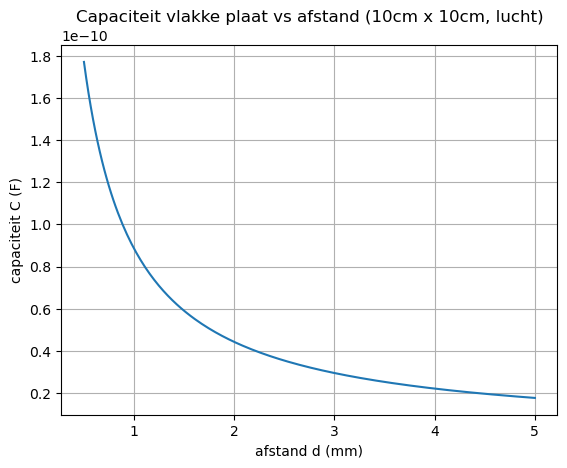

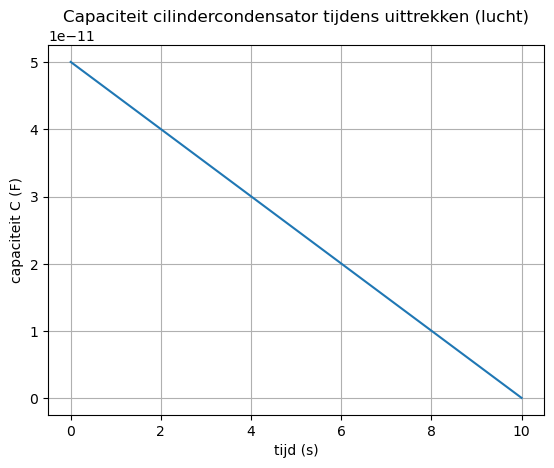

In [115]:
###
import numpy as np
import matplotlib.pyplot as plt

# --- functies uit 5a ---
def vlakkeplaat(A, d, eps_r=1.0):
    eps0 = 8.85418782e-12
    C = eps0 * eps_r * A / d
    return C

def cilinder(a, t, L, eps_r=1.0):
    eps0 = 8.85418782e-12
    C = 2 * np.pi * eps0 * eps_r * L * a / t
    return C



# 5f.1 Vlakke plaat: d lineair van 0.5 mm tot 5 mm

A = 0.10 * 0.10          # 10 cm x 10 cm -> m^2
d_start = 0.5e-3         # 0.5 mm -> m
d_end = 5e-3             # 5 mm -> m

#aantal stappen:
N = 200

#van d_start naar d_end array
d_values = np.linspace(d_start, d_end, N)

C_values = []
#C bepalen bij verschillende d
for d in d_values:
    C_values.append(vlakkeplaat(A, d, eps_r=1.0))  # lucht

plt.figure()
plt.plot(d_values * 1e3, C_values)  # x-as in mm
plt.xlabel("afstand d (mm)")
plt.ylabel("capaciteit C (F)")
plt.title("Capaciteit vlakke plaat vs afstand (10cm x 10cm, lucht)")
plt.grid(True)
plt.show()



# 5f.2 Cilinder: binnencilinder wordt in 10 s uitgetrokken
# Aanname: overlaplengte L neemt lineair af van 10 cm naar 0

D_in = 9e-3              # m
D_out = 10e-3            # m
a = D_in / 2             # binnenstraal
b = D_out / 2            # buitenstraal
t_gap = b - a            # spleet (b-a)

L0 = 0.10                # 10 cm begin overlap (m)
T = 10.0                 # 10 s  = einde
N = 200


t_values = np.linspace(0, T, N)

L_values = []
for t in t_values:
    # lineair: op t=0 is L=L0, op t=T is L=
    # L veranderd met t
    L_values.append(L0 * (1 - t / T))

C_cyl_values = []
for L in L_values:
    C_cyl_values.append(cilinder(a, t_gap, L, eps_r=1.0))  # lucht

plt.figure()
plt.plot(t_values, C_cyl_values)
plt.xlabel("tijd (s)")
plt.ylabel("capaciteit C (F)")
plt.title("Capaciteit cilindercondensator tijdens uittrekken (lucht)")
plt.grid(True)
plt.show()
###

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [116]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*
Uit Tabel I blijkt dat de capaciteitsfactor van een disk-condensator iets groter is dan die van een vierkante plaat, maar bij kleine ratio’s is het verschil slechts enkele procenten. Voor onze opstelling is 
b=0.01
b=0.01, dus nog kleiner dan de kleinste tabelwaarde 
b=0.1
b=0.1, waar het verschil al ongeveer 
1.4%
1.4% is. Met een geschatte meetonzekerheid van 3–5% is dit verschil klein genoeg om de factor van de vierkante plaat te benaderen met die van een disk-condensator


#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

Sanity check 3
Theorie vlakke plaat: 88.542 pF
Gemeten capaciteit:   28.381 pF
Idealiteitsfactor:    0.321
Afwijking vlakke plaat t.o.v. meting: -60.161 pF

Fitparameters
a = 0.002946900274037615
b = -4763.067962203859
c = -66793.93917491376
fitonzekerheid a: 0.34137507520647403

Vergelijking bij dikte spons = max
Praktische meting:             8.800 pF
Theorie zonder edge effect:    2.878 pF
Theorie met idealiteitsfactor: 0.922 pF


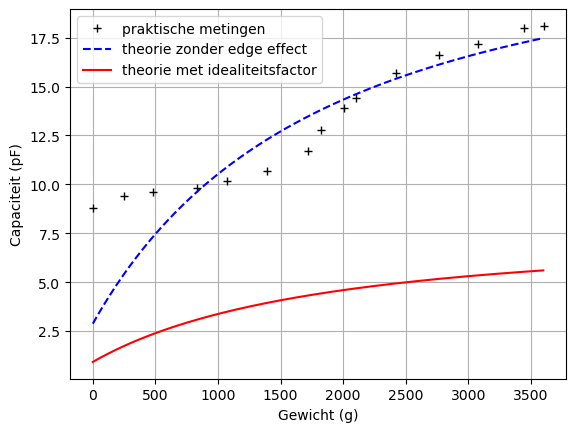

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# sanity check 3

eps0 = 8.85418782e-12
eps_r_karton = 1
A_sanity = 0.10 * 0.10
d_sanity = 1e-3
C_gemeten_sanity = 28.38116387229778  # pF

C_vlak_sanity = (eps_r_karton * eps0 * A_sanity / d_sanity) * 1e12  # pF
idealiteitsfactor = C_gemeten_sanity / C_vlak_sanity

print("Sanity check 3")
print(f"Theorie vlakke plaat: {C_vlak_sanity:.3f} pF")
print(f"Gemeten capaciteit:   {C_gemeten_sanity:.3f} pF")
print(f"Idealiteitsfactor:    {idealiteitsfactor:.3f}")
print(f"Afwijking vlakke plaat t.o.v. meting: {C_gemeten_sanity - C_vlak_sanity:.3f} pF")


# praktische sensormetingen

Marray = np.array([0,1075.6,830.4,1390.5,2103.8,2424.7,2762.7,
                   3075.1,3443.7,3603.3,2005.6,1825.2,1717.3,
                   477.5,249.2])

Carray = np.array([8.8,10.15,9.8,10.7,14.4,15.7,16.6,17.2,
                   18,18.1,13.9,12.8,11.7,9.6,9.4])


# theoretisch model

def veercapaciteit(m, a, b, c):
    D_0 = 0.04
    g = 9.81
    eps_r = 1.3
    A1 = 0.10 * 0.10
    eps0 = 8.85418782e-12

    m = m / 1000
    F = m * g
    k = a * (F - b)**2 + c
    d = D_0 - (F / k)
    C = (eps_r * eps0 * A1) / d

    return C * 1e12

# model met idealiteitsfactor
def veercapaciteit_edge(m, a, b, c):
    return idealiteitsfactor * veercapaciteit(m, a, b, c)

p0 = [1e3, 10, 1e3]

# fit oorspronkelijke theorie op de sensormetingen
popt, pcov = curve_fit(
    veercapaciteit,
    Marray,
    Carray,
    p0=p0,
    maxfev=20000
)

x_test = np.linspace(0, 3600, 1000)
y_theorie = veercapaciteit(x_test, *popt)
y_theorie_edge = veercapaciteit_edge(x_test, *popt)

print("\nFitparameters")
print("a =", popt[0])
print("b =", popt[1])
print("c =", popt[2])

onzekerheid = np.sqrt(pcov[0,0])
print("fitonzekerheid a:", onzekerheid)

# vergelijking bij dikte spons = max
C_theorie_bij_0 = veercapaciteit(0, *popt)
C_theorie_edge_bij_0 = veercapaciteit_edge(0, *popt)
C_praktijk_bij_0 = Carray[Marray == 0][0]

print("\nVergelijking bij dikte spons = max")
print(f"Praktische meting:             {C_praktijk_bij_0:.3f} pF")
print(f"Theorie zonder edge effect:    {C_theorie_bij_0:.3f} pF")
print(f"Theorie met idealiteitsfactor: {C_theorie_edge_bij_0:.3f} pF")

# plot
plt.plot(Marray, Carray, 'k+', label="praktische metingen")
plt.plot(x_test, y_theorie, 'b--', label="theorie zonder edge effect")
plt.plot(x_test, y_theorie_edge, 'r-', label="theorie met idealiteitsfactor")
plt.ylabel("Capaciteit (pF)")
plt.xlabel("Gewicht (g)")
plt.grid(True)
plt.legend()
plt.show()


##### Antwoorden 6b2

De fit lijkt slechter te fitten, komt mede doordat bij de sanity check de gemeten C waarde een stuk lager was dan de theorie, en omdat we een veranderende veerconstante hebben gefit en de a,b,c waardes niet aangepast zijn met de nieuwe curve hij eronder komt.

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.

2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*